# Économétrie - Analyse Statistique et Modélisation

## Objectif

Ce notebook réalise l'analyse statistique des données d'assurance assistance et la modélisation économétrique de la durée de traitement des dossiers.

> **Note** : Seule la base d'apprentissage (`duree_corrigee_totale > 0`) est utilisée.  
> Les dossiers TEST (`duree == 0`) sont exclus de toutes les analyses et servent uniquement pour la prédiction finale.

### Plan

**Partie 1 : Analyse Statistique Descriptive**
1. Analyse univariée (distributions)
2. Analyse bivariée (tests d'hypothèse : Kruskal-Wallis, Mann-Whitney, Spearman)
3. Analyse temporelle
4. Matrice de corrélation

**Partie 2 : Analyse Multivariée**
5. Analyse Factorielle des Données Mixtes (AFDM / FAMD)

**Partie 3 : Modélisation Économétrique (GLM)**
6. GLM Gamma (lien log)
7. GLM Inverse Gaussien (lien log)
8. Comparaison des modèles (AIC) et analyse VIF
9. Diagnostics des résidus
10. Prédictions sur les dossiers TEST

---

## 1. Import des Bibliothèques

In [1]:
# IMPORT DES BIBLIOTHEQUES

import pandas as pd                                
import numpy as np                                 
import matplotlib.pyplot as plt                    
import seaborn as sns                              

from scipy.stats import (
    spearmanr,                                     # Corrélation de Spearman (rang)
    shapiro,                                       # Test de normalité de Shapiro-Wilk
    levene,                                        # Test d'égalité des variances
    f_oneway,                                      # ANOVA (comparaison de moyennes)
    kruskal,                                       # Kruskal-Wallis (ANOVA non-param.)
    mannwhitneyu                                   # Mann-Whitney U (2 groupes non-param.)
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd  # Post-hoc Tukey HSD

import statsmodels.api as sm                       # Modèles statistiques (GLM, OLS)
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF
from sklearn.model_selection import train_test_split  # Split train/validation

import prince                                      # Analyse factorielle (FAMD/AFDM)
from sklearn.preprocessing import StandardScaler   # Standardisation

# Configuration graphique 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des Données

In [2]:
# base_model.csv contient uniquement les dossiers TRAIN (durée > 0)
# base_test.csv contient les dossiers TEST (durée == 0), utilisés pour la prédiction finale

base = pd.read_csv('../data/processed/base_model.csv')
base_test = pd.read_csv('../data/processed/base_test.csv')

# Création d'une variable log pour les analyses graphiques
# La durée est très asymétrique, le log la rend plus interprétable
base['log_duree'] = np.log1p(base['duree_corrigee_totale'])  # log(1 + durée)

print(f"Base TRAIN : {base.shape[0]} lignes x {base.shape[1]} colonnes")
print(f"Base TEST  : {base_test.shape[0]} lignes x {base_test.shape[1]} colonnes")
print(f"Statistiques de la variable cible (durée en secondes) :")
base['duree_corrigee_totale'].describe()

Base TRAIN : 86950 lignes x 35 colonnes
Base TEST  : 13041 lignes x 34 colonnes
Statistiques de la variable cible (durée en secondes) :


count    86950.000000
mean      1338.183813
std       2013.348247
min          5.000000
25%        356.000000
50%        659.000000
75%       1442.000000
max      58720.000000
Name: duree_corrigee_totale, dtype: float64

# PARTIE 1 : ANALYSE STATISTIQUE DESCRIPTIVE

## 3. Analyse Univariee

Objectif : comprendre la distribution de chaque variable individuellement.

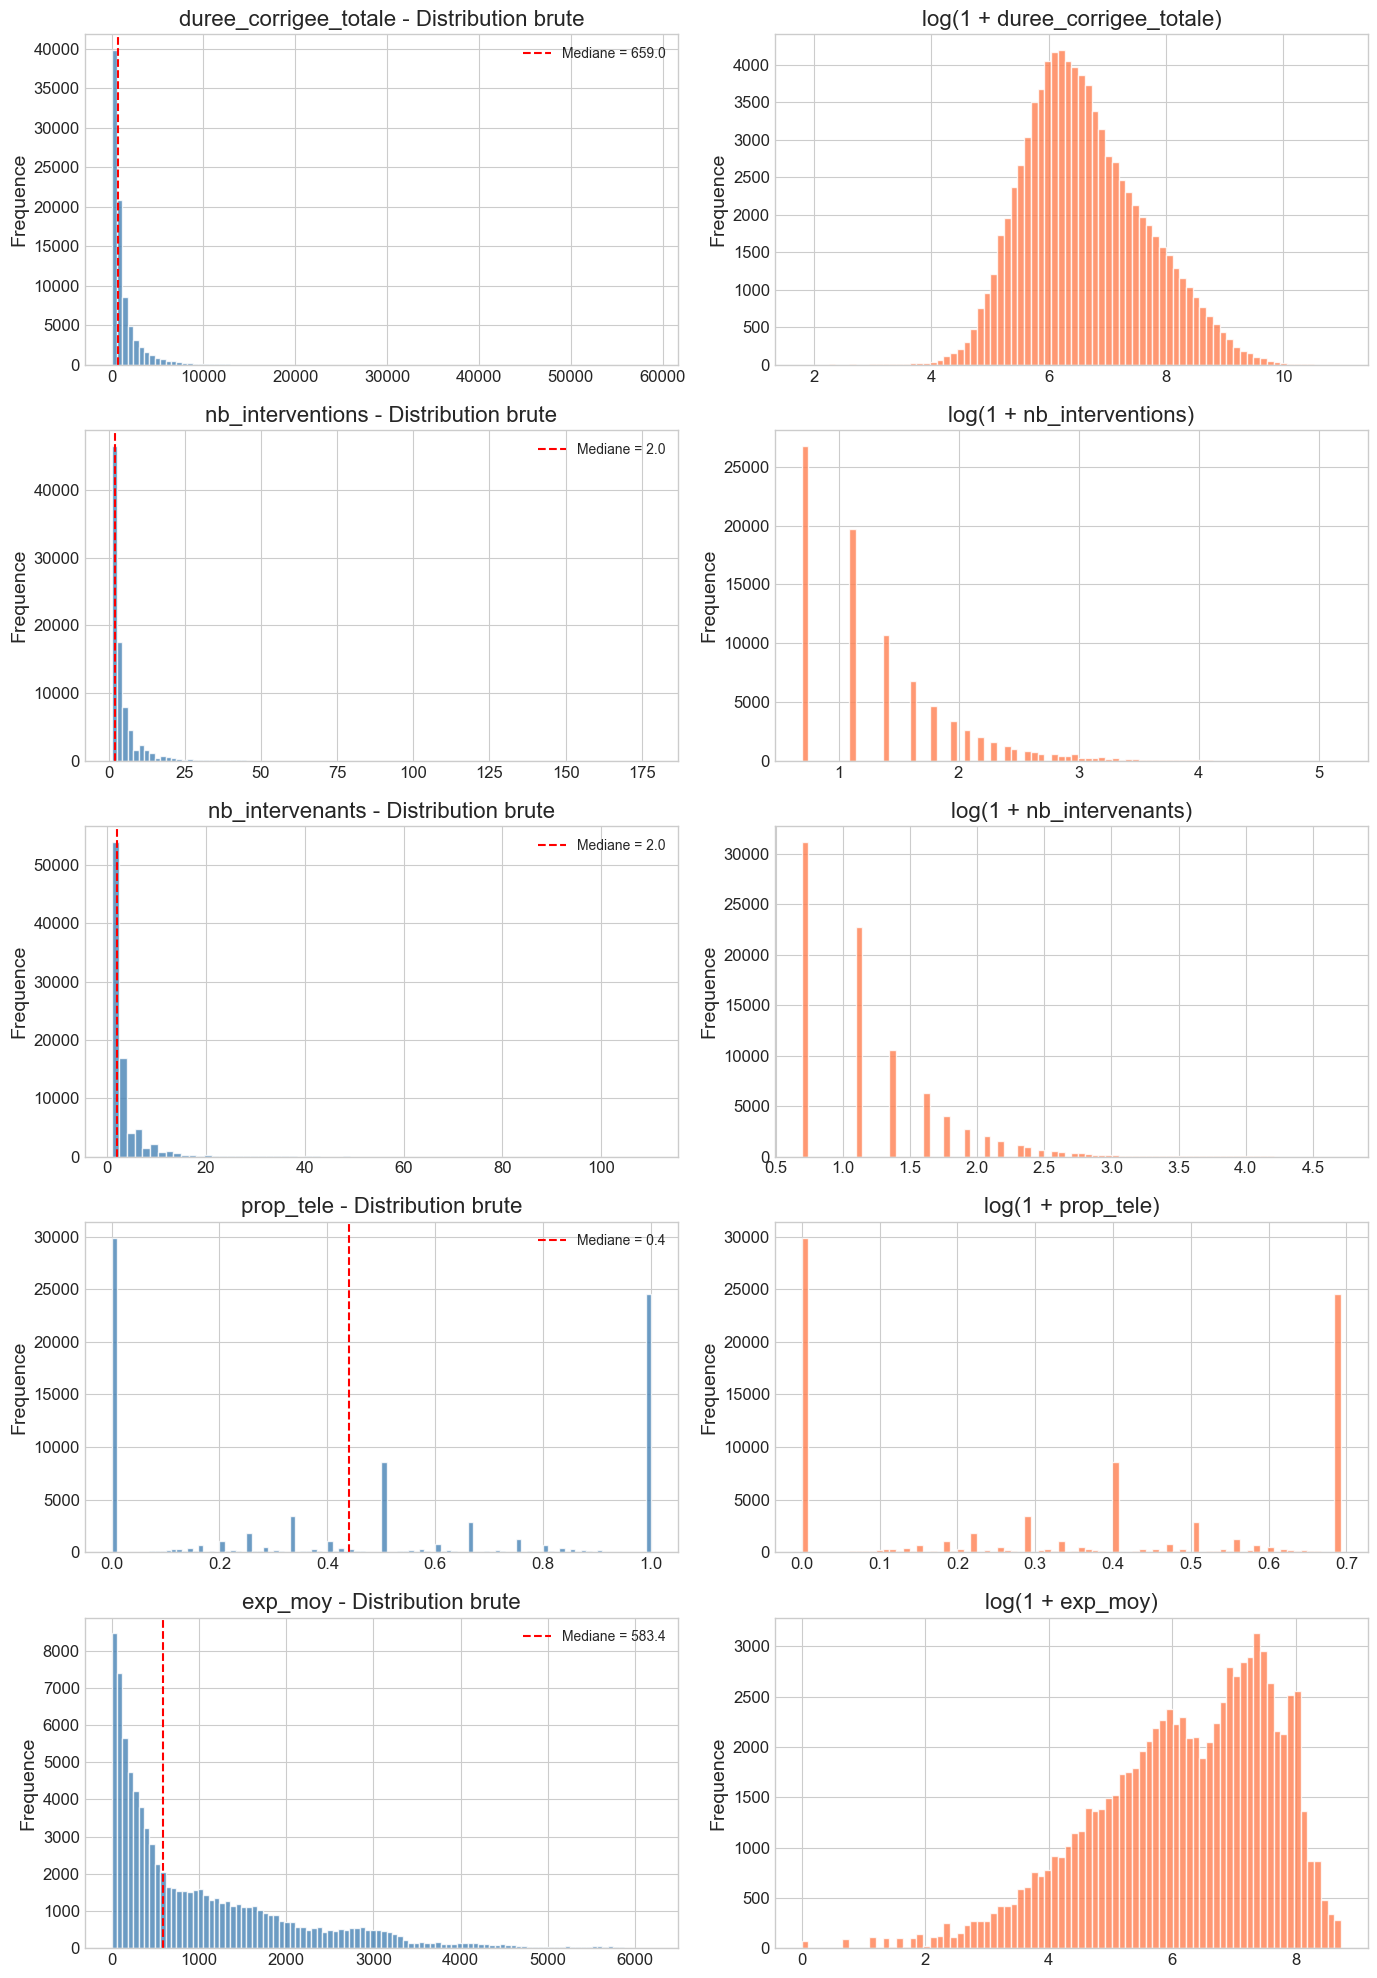

In [3]:
# DISTRIBUTIONS DES VARIABLES NUMERIQUES

# Liste des variables numeriques d'interet
num_vars = ['duree_corrigee_totale', 'nb_interventions', 'nb_intervenants', 'prop_tele', 'exp_moy']

fig, axes = plt.subplots(len(num_vars), 2, figsize=(14, 4 * len(num_vars)))  # Grille de graphiques

for i, var in enumerate(num_vars):                   # Pour chaque variable
    # --- Colonne gauche : distribution brute ---
    axes[i, 0].hist(
        base[var].dropna(),                          # Valeurs sans NaN
        bins=min(100, base[var].nunique()),           # Nombre de barres adapte
        color='steelblue',                            # Couleur
        edgecolor='white',                            # Bordure blanche
        alpha=0.8                                     # Transparence
    )
    axes[i, 0].set_title(f'{var} - Distribution brute')  # Titre
    axes[i, 0].set_ylabel('Frequence')                    # Label Y
    # Ajout de la mediane
    median_val = base[var].median()                        # Calcul de la mediane
    axes[i, 0].axvline(median_val, color='red', linestyle='--',  # Ligne verticale
                       label=f'Mediane = {median_val:.1f}')
    axes[i, 0].legend(fontsize=10)                         # Legende

    # --- Colonne droite : distribution log(1+x) ---
    axes[i, 1].hist(
        np.log1p(base[var].dropna()),                 # Transformation log
        bins=80,                                       # Nombre de barres
        color='coral',                                 # Couleur
        edgecolor='white',                             # Bordure
        alpha=0.8                                      # Transparence
    )
    axes[i, 1].set_title(f'log(1 + {var})')            # Titre
    axes[i, 1].set_ylabel('Frequence')                  # Label Y

plt.tight_layout()                                      # Ajustement des marges
plt.show()                                              # Affichage

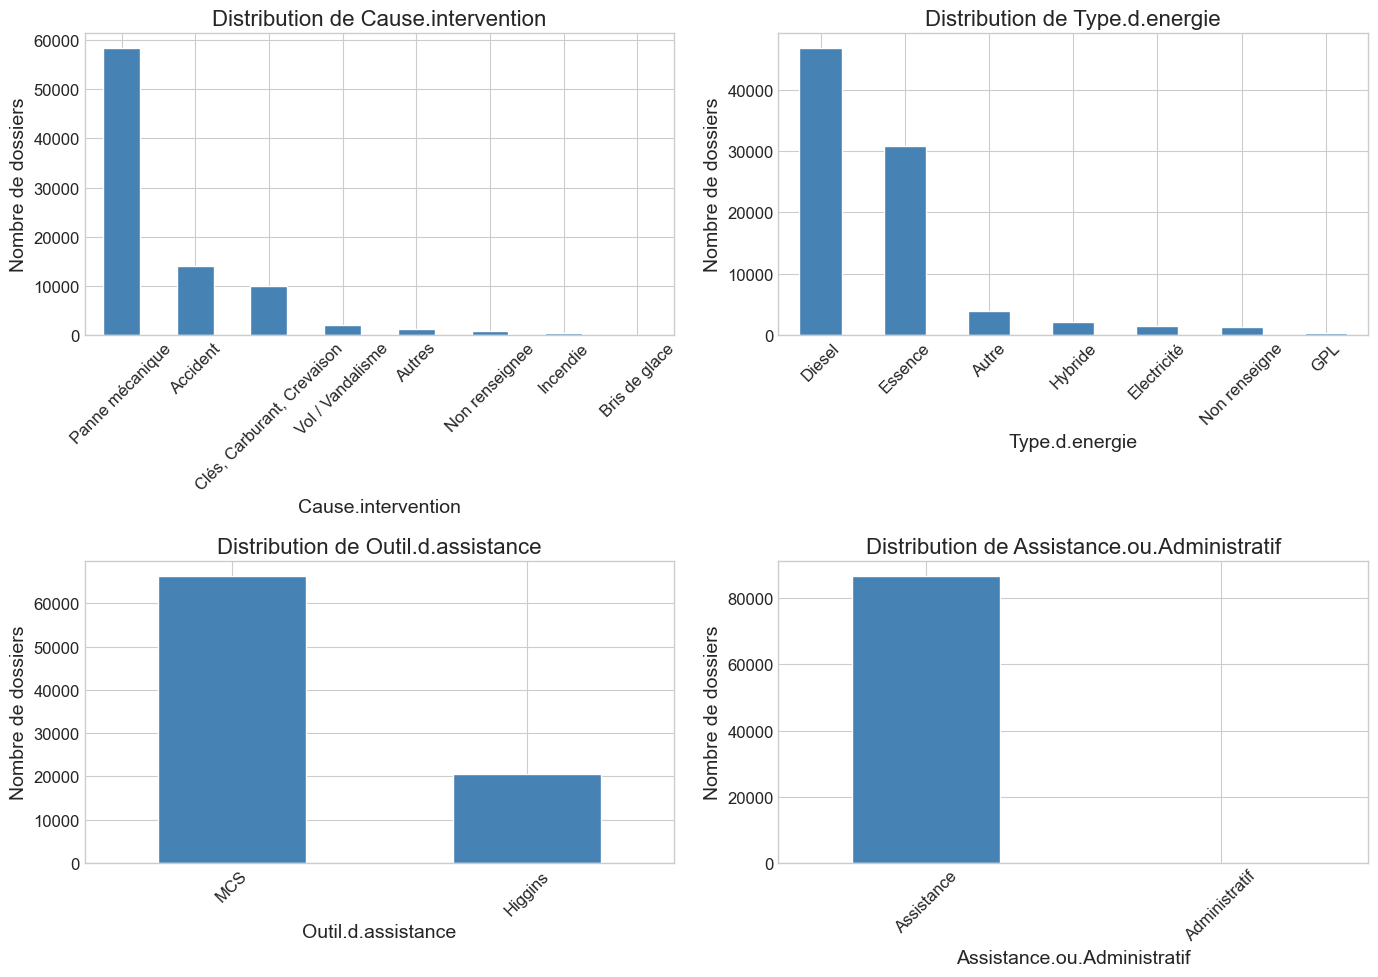

In [4]:
# DISTRIBUTIONS DES VARIABLES CATEGORIELLES

# Variables catégorielles 
cat_vars = ['Cause.intervention', 'Type.d.energie', 'Outil.d.assistance', 'Assistance.ou.Administratif']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))        # Grille 2x2
axes = axes.flatten()                                    # Aplatir pour iterer

for i, var in enumerate(cat_vars):                       # Pour chaque variable
    counts = base[var].value_counts()                    # Comptage par modalite
    counts.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')  # Barplot
    axes[i].set_title(f'Distribution de {var}')          # Titre
    axes[i].set_ylabel('Nombre de dossiers')             # Label Y
    axes[i].tick_params(axis='x', rotation=45)           # Rotation des labels

plt.tight_layout()                                       # Ajustement
plt.show()                                               # Affichage

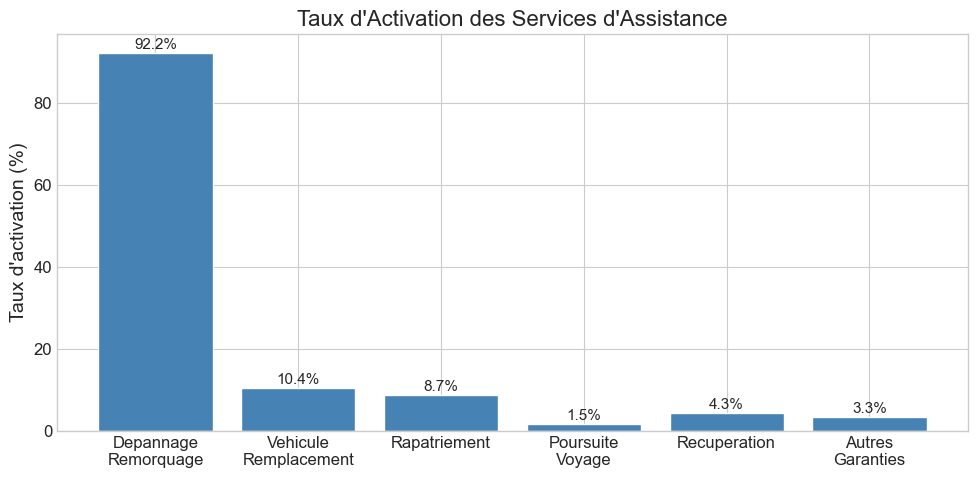

In [5]:
# DISTRIBUTION DES VARIABLES BINAIRES (TOP)

# Variables TOP : services d'assistance actives (0 ou 1)
top_vars = ['TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup', 'TOP.Autres.Garanties']
top_labels = ['Depannage\nRemorquage', 'Vehicule\nRemplacement', 'Rapatriement', 'Poursuite\nVoyage', 'Recuperation', 'Autres\nGaranties']

# Calcul du taux d'activation de chaque service
taux = [base[v].mean() * 100 for v in top_vars]          # Pourcentage d'activation

fig, ax = plt.subplots(figsize=(10, 5))                   # Figure
bars = ax.bar(top_labels, taux, color='steelblue', edgecolor='white')  # Barplot

# Ajout des valeurs au-dessus des barres
for bar, val in zip(bars, taux):                          # Pour chaque barre
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,  # Position
            f'{val:.1f}%', ha='center', fontsize=11)      # Texte

ax.set_ylabel('Taux d\'activation (%)')                   # Label Y
ax.set_title('Taux d\'Activation des Services d\'Assistance')  # Titre
plt.tight_layout()                                         # Ajustement
plt.show()                                                 # Affichage

## 4. Analyse Bivariée

**Question centrale** : Qu'est-ce qui influence la duree de traitement d'un dossier ?

### 4.1. Impact de la cause d'intervention

=== Statistiques de la duree par cause d'intervention ===
Cause.intervention      Accident        Autres  Bris de glace  \
count               13987.000000   1292.000000      99.000000   
mean                 1724.421432   1160.505412    2463.137596   
std                  2012.459862   2624.585539    3566.958932   
min                    10.000000      9.000000     230.000000   
25%                   574.000000    323.000000     644.500000   
50%                  1013.000000    540.000000    1419.000000   
75%                  2068.500000    910.250000    2335.500000   
max                 28304.000000  41732.748000   17799.000000   

Cause.intervention  Clés, Carburant, Crevaison      Incendie  Non renseignee  \
count                              9966.000000    358.000000      843.000000   
mean                                841.156769   2521.094268     1430.327841   
std                                1215.646929   3198.651042     2078.036829   
min                                 

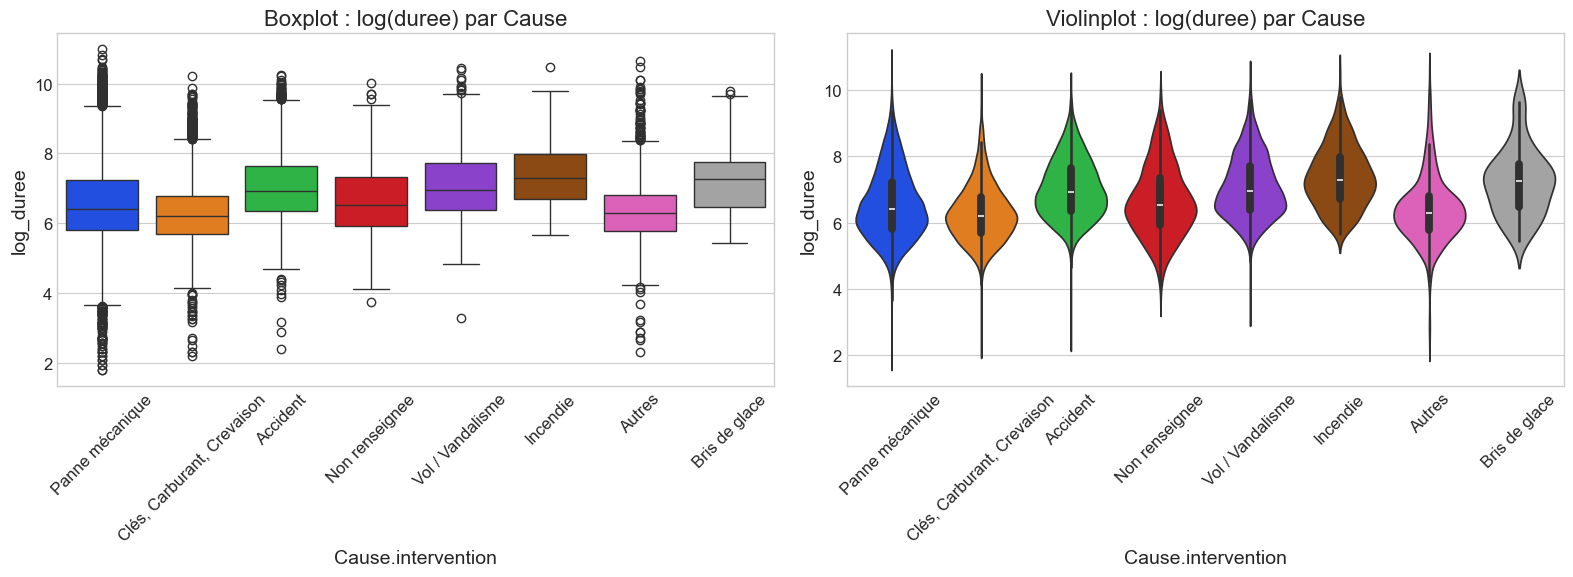

In [6]:
# DUREE PAR CAUSE D'INTERVENTION

# Statistiques descriptives par cause
print("=== Statistiques de la duree par cause d'intervention ===")
print(base.groupby('Cause.intervention')['duree_corrigee_totale'].describe().T)  # Stats transposees

# Graphiques boxplot et violinplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))          # 2 graphiques

# --- Boxplot ---
sns.boxplot(
    data=base, x='Cause.intervention', y='log_duree',    # Variables
    hue='Cause.intervention',                             # Couleur par cause
    palette='bright', legend=False, ax=axes[0]            # Style
)
axes[0].set_title('Boxplot : log(duree) par Cause')       # Titre
axes[0].tick_params(axis='x', rotation=45)                # Rotation

# --- Violinplot ---
sns.violinplot(
    data=base, x='Cause.intervention', y='log_duree',    # Variables
    hue='Cause.intervention',                             # Couleur
    palette='bright', legend=False, ax=axes[1]            # Style
)
axes[1].set_title('Violinplot : log(duree) par Cause')    # Titre
axes[1].tick_params(axis='x', rotation=45)                # Rotation

plt.tight_layout()                                         # Ajustement
plt.show()                                                 # Affichage

In [7]:
# TESTS STATISTIQUES : DUREE vs CAUSE D'INTERVENTION

# Creation des groupes de durees par cause
groups_cause = [
    group['duree_corrigee_totale'].dropna()               # Durees par groupe
    for _, group in base.groupby('Cause.intervention')    # Grouper par cause
]

# --- Test 1 : Normalite (Shapiro-Wilk) par groupe ---
print("=== Test de Normalite (Shapiro-Wilk) ===")
print("H0 : la distribution est normale")
print("H1 : la distribution n'est pas normale\n")
for name, group in base.groupby('Cause.intervention'):   # Pour chaque cause
    g = group['duree_corrigee_totale'].dropna()           # Durees sans NaN
    stat, p = shapiro(g.sample(min(5000, len(g)), random_state=42))  # Test (sous-echantillon)
    print(f"  {name:35s} : stat={stat:.4f}, p={p:.3e} -> {'Normal' if p > 0.05 else 'Non normal'}")  # Resultat

# --- Test 2 : Egalite des variances (Levene) ---
print("\n=== Test d'Egalite des Variances (Levene) ===")
print("H0 : les variances sont egales dans tous les groupes")
stat_lev, p_lev = levene(*groups_cause)                   # Test de Levene
print(f"  stat={stat_lev:.3f}, p={p_lev:.3e} -> {'Variances egales' if p_lev > 0.05 else 'Variances inegales'}")

# --- Test 3 : Kruskal-Wallis (ANOVA non-parametrique) ---
# Utilise car la normalite et l'egalite des variances ne sont PAS verifiees
print("\n=== Test de Kruskal-Wallis ===")
print("H0 : la duree mediane est identique dans tous les groupes")
print("H1 : au moins un groupe differe")
stat_kw, p_kw = kruskal(*groups_cause)                    # Test de Kruskal-Wallis
print(f"  stat={stat_kw:.3f}, p={p_kw:.3e}")
print(f"  -> {'Pas de difference significative' if p_kw > 0.05 else 'Difference significative (p < 0.05)'}")

=== Test de Normalite (Shapiro-Wilk) ===
H0 : la distribution est normale
H1 : la distribution n'est pas normale

  Accident                            : stat=0.6693, p=1.831e-71 -> Non normal
  Autres                              : stat=0.3290, p=5.929e-56 -> Non normal
  Bris de glace                       : stat=0.5733, p=1.652e-15 -> Non normal
  Clés, Carburant, Crevaison          : stat=0.5073, p=7.860e-80 -> Non normal
  Incendie                            : stat=0.5978, p=5.288e-28 -> Non normal
  Non renseignee                      : stat=0.5873, p=1.254e-40 -> Non normal
  Panne mécanique                     : stat=0.5673, p=4.704e-77 -> Non normal
  Vol / Vandalisme                    : stat=0.5754, p=1.541e-56 -> Non normal

=== Test d'Egalite des Variances (Levene) ===
H0 : les variances sont egales dans tous les groupes
  stat=111.377, p=2.555e-163 -> Variances inegales

=== Test de Kruskal-Wallis ===
H0 : la duree mediane est identique dans tous les groupes
H1 : au moins

In [8]:
# POST-HOC : TEST DE TUKEY HSD
# Identifie quels couples de causes sont significativement differents

tukey_cause = pairwise_tukeyhsd(
    endog=base['duree_corrigee_totale'],              # Variable dependante
    groups=base['Cause.intervention'],                 # Groupes
    alpha=0.05                                         # Seuil de significativite
)

print("=== Post-hoc Tukey HSD : Cause d'intervention ===")
print(tukey_cause)                                     # Tableau des comparaisons

=== Post-hoc Tukey HSD : Cause d'intervention ===
                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                         
          group1                     group2            meandiff  p-adj    lower      upper    reject
----------------------------------------------------------------------------------------------------
                  Accident                     Autres   -563.916    0.0  -739.8438  -387.9883   True
                  Accident              Bris de glace   738.7162  0.006   128.4851  1348.9473   True
                  Accident Clés, Carburant, Crevaison  -883.2647    0.0  -962.5764  -803.9529   True
                  Accident                   Incendie   796.6728    0.0   472.8355  1120.5101   True
                  Accident             Non renseignee  -294.0936 0.0009  -508.6665   -79.5207   True
                  Accident            Panne mécanique  -420.8935    0.0  -477.8477  -363.9394   True
                  Accident           Vol 

**Interpretation** :  
- p-value < 0.05 pour Kruskal-Wallis : la duree de traitement differe significativement selon la cause d'intervention.  
- Le test de Tukey identifie les couples de causes qui different significativement.

### 4.2. Impact du type d'energie

=== Duree par Type d'Energie ===
Type.d.energie         Autre        Diesel   Electricité       Essence  \
count            4001.000000  46879.000000   1484.000000  30863.000000   
mean             1450.937228   1411.574842   1657.757826   1178.946305   
std              2164.161091   2105.638360   2422.630868   1718.679921   
min                 9.000000      5.000000     25.000000      5.000000   
25%               385.000000    365.000000    434.000000    336.000000   
50%               717.000000    685.000000    780.500000    610.000000   
75%              1565.000000   1542.000000   1845.000000   1266.000000   
max             35671.000000  50095.748000  25941.000000  34946.000000   

Type.d.energie           GPL       Hybride  Non renseigne  
count             334.000000   2103.000000    1286.000000  
mean             1287.113772   1570.690139    1397.881700  
std              1665.951322   2918.283010    2129.601571  
min                14.000000     12.000000      37.000000  


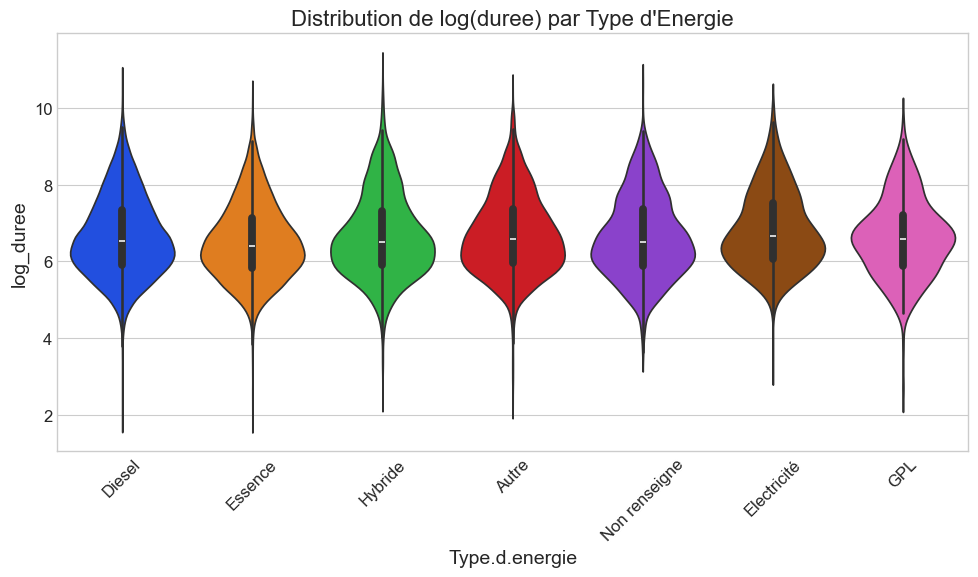


Kruskal-Wallis : stat=364.713, p=1.070e-75
-> Difference significative

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1       group2     meandiff p-adj    lower     upper   reject
---------------------------------------------------------------------
      Autre        Diesel  -39.3624 0.8985  -136.947   58.2222  False
      Autre   Electricité  206.8206 0.0126   26.7394  386.9018   True
      Autre       Essence -271.9909    0.0 -371.5467 -172.4351   True
      Autre           GPL -163.8235 0.7849 -501.2804  173.6334  False
      Autre       Hybride  119.7529 0.2886  -39.8294  279.3352  False
      Autre Non renseigne  -53.0555 0.9826 -242.9801   136.869  False
     Diesel   Electricité   246.183 0.0001   89.9647  402.4012   True
     Diesel       Essence -232.6285    0.0 -276.0596 -189.1974   True
     Diesel           GPL -124.4611 0.9197 -449.8102  200.8881  False
     Diesel       Hybride  159.1153  0.007   27.0494  291.1812   True
     Diesel Non r

In [9]:
# DUREE PAR TYPE D'ENERGIE

# Statistiques descriptives
print("=== Duree par Type d'Energie ===")
print(base.groupby('Type.d.energie')['duree_corrigee_totale'].describe().T)

# Violinplot
plt.figure(figsize=(10, 6))                                # Figure
sns.violinplot(
    data=base, x='Type.d.energie', y='log_duree',         # Variables
    hue='Type.d.energie', palette='bright', legend=False   # Style
)
plt.title('Distribution de log(duree) par Type d\'Energie')  # Titre
plt.xticks(rotation=45)                                     # Rotation labels
plt.tight_layout()                                          # Ajustement
plt.show()                                                  # Affichage

# Test de Kruskal-Wallis
groups_energie = [g['duree_corrigee_totale'].dropna() for _, g in base.groupby('Type.d.energie')]
stat, p = kruskal(*groups_energie)                          # Test
print(f"\nKruskal-Wallis : stat={stat:.3f}, p={p:.3e}")
print(f"-> {'Difference significative' if p < 0.05 else 'Pas de difference'}")

# Post-hoc Tukey
tukey_energie = pairwise_tukeyhsd(base['duree_corrigee_totale'], base['Type.d.energie'], alpha=0.05)
print(f"\n{tukey_energie}")

### 4.3. Impact des garanties (variables TOP)

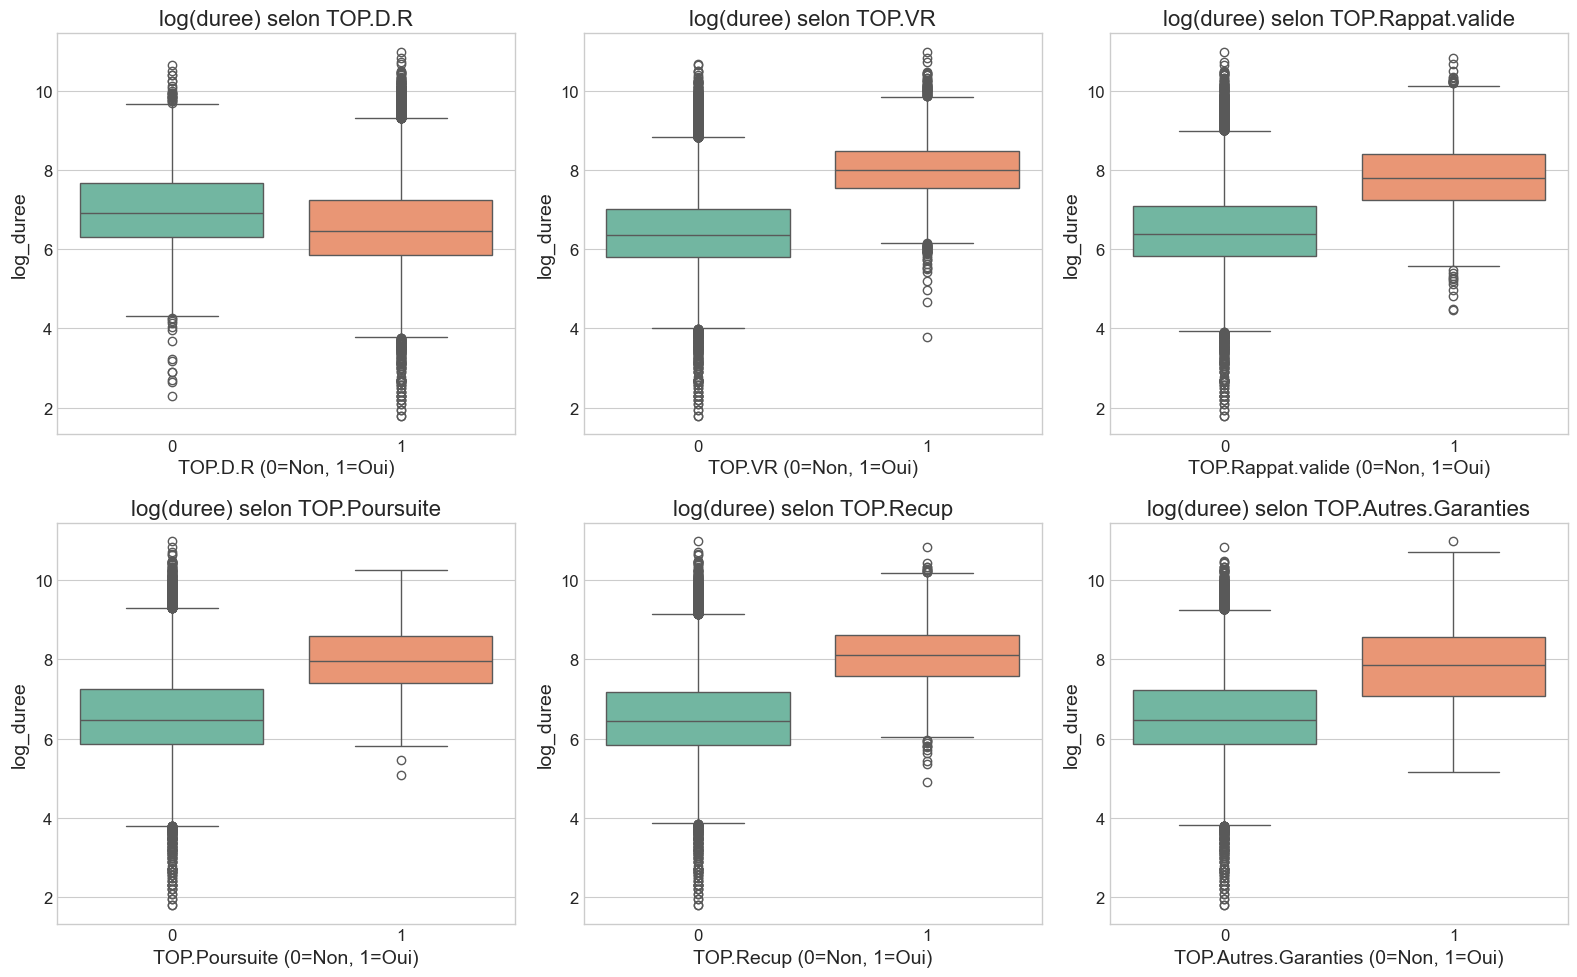


=== Tests de Mann-Whitney U (2 groupes) ===
H0 : pas de difference de duree entre les 2 groupes
Variable                        Stat      p-value                Conclusion
------------------------------------------------------------------------
TOP.D.R                    341577045   1.344e-260  Difference significative
TOP.VR                      67947044    0.000e+00  Difference significative
TOP.Rappat.valide           87636565    0.000e+00  Difference significative
TOP.Poursuite               15702069    0.000e+00  Difference significative
TOP.Recup                   34825006    0.000e+00  Difference significative
TOP.Autres.Garanties        43870477    0.000e+00  Difference significative


In [10]:
# DUREE PAR SERVICE D'ASSISTANCE (VARIABLES TOP)

# Boxplots de la duree selon l'activation de chaque service
fig, axes = plt.subplots(2, 3, figsize=(16, 10))          # Grille 2x3
axes = axes.flatten()                                      # Aplatir

for i, var in enumerate(top_vars):                         # Pour chaque variable TOP
    sns.boxplot(
        data=base, x=var, y='log_duree',                  # Variables
        hue=var, palette='Set2', legend=False, ax=axes[i]  # Style
    )
    axes[i].set_title(f'log(duree) selon {var}')           # Titre
    axes[i].set_xlabel(f'{var} (0=Non, 1=Oui)')            # Label X

plt.tight_layout()                                         # Ajustement
plt.show()                                                 # Affichage

# Tests de Mann-Whitney pour chaque variable TOP
print("\n=== Tests de Mann-Whitney U (2 groupes) ===")
print("H0 : pas de difference de duree entre les 2 groupes")
print(f"{'Variable':<25} {'Stat':>10} {'p-value':>12} {'Conclusion':>25}")
print('-' * 72)

for var in top_vars:                                       # Pour chaque TOP
    group0 = base[base[var] == 0]['duree_corrigee_totale']  # Groupe sans le service
    group1 = base[base[var] == 1]['duree_corrigee_totale']  # Groupe avec le service
    stat, p = mannwhitneyu(group0, group1)                  # Test de Mann-Whitney
    conclusion = 'Difference significative' if p < 0.05 else 'Pas de difference'
    print(f"{var:<25} {stat:>10.0f} {p:>12.3e} {conclusion:>25}")

**Interpretation** :  
- Le service D/R (Depannage/Remorquage) **reduit** la duree (car dossiers simples)  
- Les services VR, Rapatriement, Poursuite **augmentent** la duree (dossiers complexes)  
- Tous les tests sont significatifs (p < 0.05)

### 4.4. Impact des variables numeriques

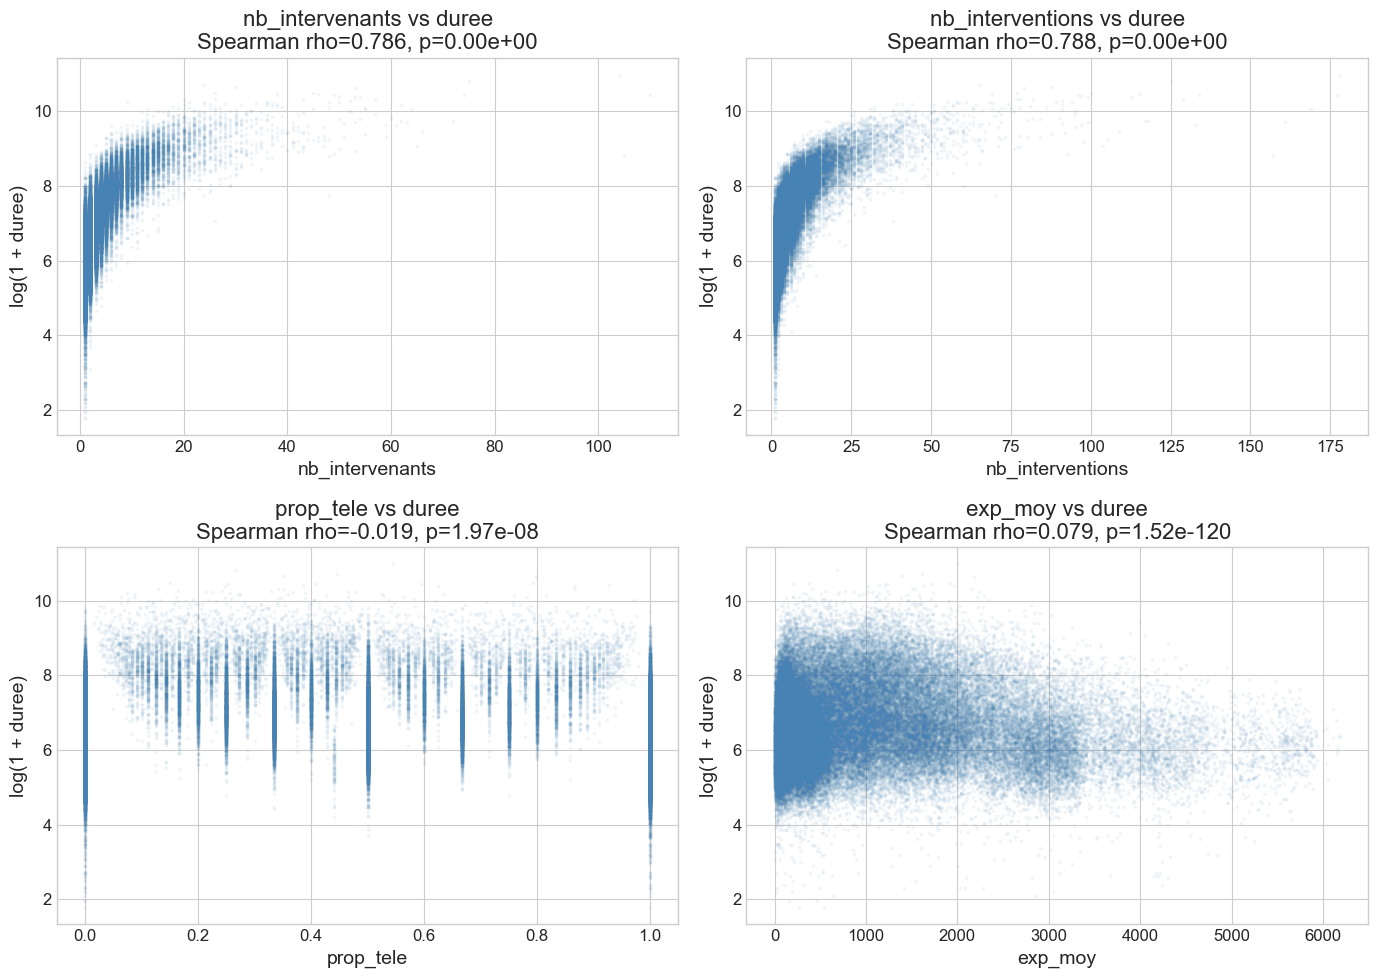


=== Correlations de Spearman avec la duree ===
  nb_intervenants      : rho=+0.786 (correlation positive), p=0.00e+00
  nb_interventions     : rho=+0.788 (correlation positive), p=0.00e+00
  prop_tele            : rho=-0.019 (correlation negative), p=1.97e-08
  exp_moy              : rho=+0.079 (correlation positive), p=1.52e-120


In [11]:
# CORRELATIONS AVEC LA DUREE DE TRAITEMENT

# Variables numeriques explicatives
explicatives = ['nb_intervenants', 'nb_interventions', 'prop_tele', 'exp_moy']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))          # Grille 2x2
axes = axes.flatten()                                      # Aplatir

for i, var in enumerate(explicatives):                     # Pour chaque variable
    # Scatterplot
    axes[i].scatter(
        base[var], base['log_duree'],                      # X et Y
        alpha=0.05, s=3, color='steelblue'                 # Style
    )
    axes[i].set_xlabel(var)                                 # Label X
    axes[i].set_ylabel('log(1 + duree)')                    # Label Y
    
    # Correlation de Spearman
    rho, p = spearmanr(base[var], base['duree_corrigee_totale'])  # Test de correlation
    axes[i].set_title(f'{var} vs duree\nSpearman rho={rho:.3f}, p={p:.2e}')  # Titre avec resultat

plt.tight_layout()                                         # Ajustement
plt.show()                                                 # Affichage

# Resume des correlations
print("\n=== Correlations de Spearman avec la duree ===")
for var in explicatives:
    rho, p = spearmanr(base[var], base['duree_corrigee_totale'])
    sens = 'positive' if rho > 0 else 'negative'
    print(f"  {var:<20} : rho={rho:+.3f} (correlation {sens}), p={p:.2e}")

### 4.5. Analyse temporelle

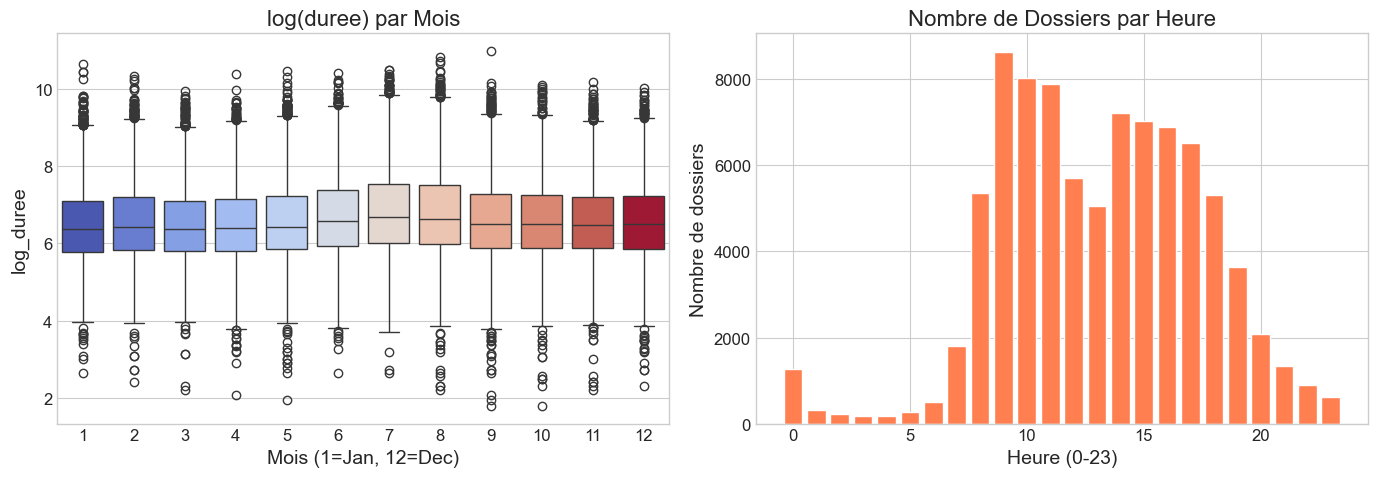

In [12]:
# ANALYSE TEMPORELLE DE LA DUREE

# Conversion de la date d'ouverture en datetime
base['date.ouverture'] = pd.to_datetime(base['date.ouverture'])  # Parsing
base['mois'] = base['date.ouverture'].dt.month                    # Extraction du mois
base['heure'] = pd.to_datetime(base['heure.ouverture'], format='%H:%M:%S').dt.hour  # Extraction heure

fig, axes = plt.subplots(1, 2, figsize=(14, 5))           # 2 graphiques

# --- Duree par mois ---
sns.boxplot(
    data=base, x='mois', y='log_duree',                   # Variables
    hue='mois', palette='coolwarm', legend=False, ax=axes[0]  # Style
)
axes[0].set_title('log(duree) par Mois')                   # Titre
axes[0].set_xlabel('Mois (1=Jan, 12=Dec)')                 # Label X

# --- Volume par heure ---
heure_counts = base['heure'].value_counts().sort_index()   # Comptage par heure
axes[1].bar(heure_counts.index, heure_counts.values, color='coral', edgecolor='white')  # Barplot
axes[1].set_title('Nombre de Dossiers par Heure')          # Titre
axes[1].set_xlabel('Heure (0-23)')                          # Label X
axes[1].set_ylabel('Nombre de dossiers')                    # Label Y

plt.tight_layout()                                          # Ajustement
plt.show()                                                  # Affichage

### 4.6. Matrice de Correlation

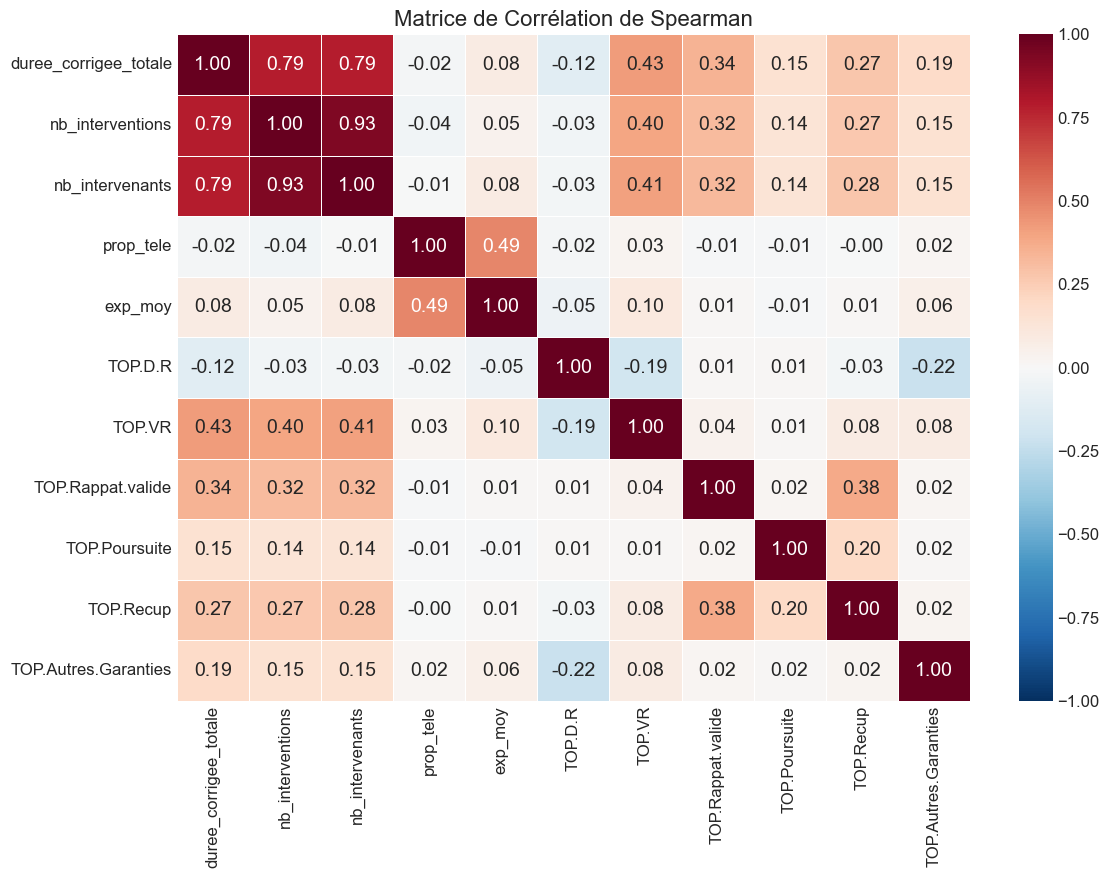

In [13]:
# ============================================================
# MATRICE DE CORRELATION DE SPEARMAN
# ============================================================
# On utilise Spearman car les variables ne sont pas normales

# Variables pour la matrice de corrélation
corr_vars = ['duree_corrigee_totale', 'nb_interventions', 'nb_intervenants',
             'prop_tele', 'exp_moy'] + top_vars              # Numériques + binaires

# Calcul de la matrice de corrélation de Spearman
corr_matrix = base[corr_vars].corr(method='spearman')       # Matrice

# Heatmap avec masque triangulaire supérieur
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))        # Masque triangulaire
sns.heatmap(
    corr_matrix,
    # mask=mask,                                                # Application du masque
    annot=True,                                               # Afficher les valeurs
    fmt='.2f',                                                # Format 2 décimales
    cmap='RdBu_r',                                            # Palette rouge-bleu
    center=0,                                                 # Centre à zéro
    linewidths=0.5,                                           # Largeur des lignes
    vmin=-1, vmax=1                                           # Limites de l'échelle
)
plt.title('Matrice de Corrélation de Spearman', fontsize=16)
plt.tight_layout()
plt.show()

# PARTIE 2 : ANALYSE MULTIVARIEE

## 5. Analyse Factorielle des Donnees Mixtes (AFDM / FAMD)

L'AFDM permet de reduire la dimension sur des donnees **mixtes** (quantitatives + qualitatives).  
Elle combine ACP (pour les numeriques) et ACM (pour les categorielles).

In [14]:
# PREPARATION DES DONNEES POUR L'AFDM

# Variable cible (exclue des features pour l'analyse non supervisee)
target = 'duree_corrigee_totale'

# Variables explicatives quantitatives
var_quanti = ['nb_interventions', 'nb_intervenants', 'exp_moy', 'prop_tele']

# Variables explicatives categorielles
var_quali = [
    'Client', 'Formule', 'Cause.intervention', 'Type.d.energie',
    'Outil.d.assistance', 'Assistance.ou.Administratif',
    'pop_mode', 'site_mode', 'type_contrat_mode'
]

# Variables binaires (traitees comme categorielles pour l'AFDM)
var_bin = ['TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup', 'TOP.Autres.Garanties']

# Construction de la matrice d'analyse
features_afdm = var_quanti + var_quali + var_bin           # Toutes les features
data_afdm = base[features_afdm].dropna()                   # Suppression des NaN

print(f"Donnees pour l'AFDM : {data_afdm.shape[0]} lignes x {data_afdm.shape[1]} colonnes")

Donnees pour l'AFDM : 86950 lignes x 19 colonnes


In [15]:
# AJUSTEMENT DE L'AFDM (FAMD)

# FAMD avec 5 composantes
famd = prince.FAMD(
    n_components=5,              # Nombre de dimensions a extraire
    random_state=42              # Reproductibilite
)
famd = famd.fit(data_afdm)       # Ajustement sur les donnees

# Coordonnees factorielles des individus (dossiers)
coord = famd.row_coordinates(data_afdm)  # Projection des individus
coord.columns = ['Dim1', 'Dim2', 'Dim3', 'Dim4', 'Dim5']  # Renommage des colonnes

# Variance expliquee par chaque dimension
eig = famd.eigenvalues_                                # Valeurs propres
explained = eig / eig.sum()                             # Proportions
cumul = np.cumsum(explained)                            # Cumul

print("=== Variance expliquee par dimension ===")
for i, (e, c) in enumerate(zip(explained, cumul)):      # Pour chaque dimension
    print(f"  Dim{i+1} : {e*100:.1f}% (cumul : {c*100:.1f}%)")

=== Variance expliquee par dimension ===
  Dim1 : 24.1% (cumul : 24.1%)
  Dim2 : 19.7% (cumul : 43.8%)
  Dim3 : 19.4% (cumul : 63.2%)
  Dim4 : 18.5% (cumul : 81.7%)
  Dim5 : 18.3% (cumul : 100.0%)


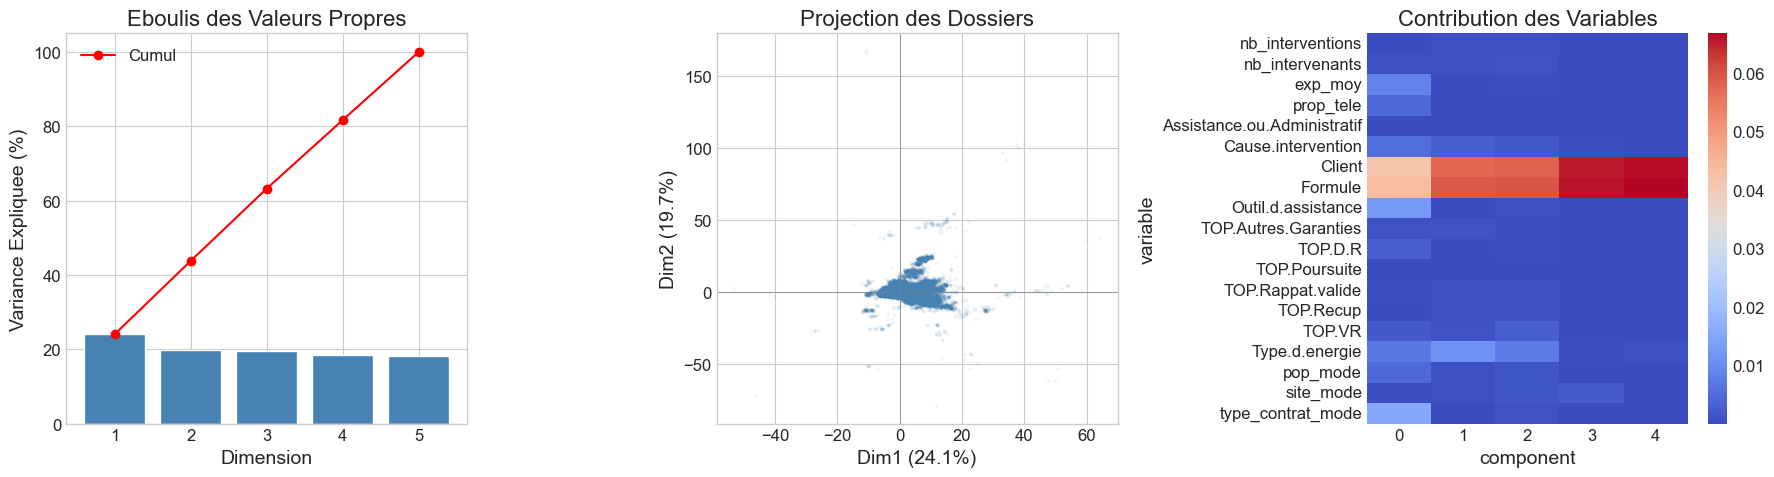

In [16]:
# VISUALISATION DE L'AFDM

fig, axes = plt.subplots(1, 3, figsize=(18, 5))            # 3 graphiques

# --- 1. Eboulis des valeurs propres ---
axes[0].bar(range(1, len(explained)+1), explained*100, color='steelblue', edgecolor='white')  # Barres
axes[0].plot(range(1, len(explained)+1), cumul*100, 'ro-', label='Cumul')  # Courbe cumul
axes[0].set_xlabel('Dimension')                             # Label X
axes[0].set_ylabel('Variance Expliquee (%)')                # Label Y
axes[0].set_title('Eboulis des Valeurs Propres')            # Titre
axes[0].legend()                                            # Legende

# --- 2. Projection des dossiers (Dim1 x Dim2) ---
axes[1].scatter(coord['Dim1'], coord['Dim2'], alpha=0.05, s=3, color='steelblue')  # Nuage
axes[1].axhline(0, color='grey', linewidth=0.5)             # Axe horizontal
axes[1].axvline(0, color='grey', linewidth=0.5)             # Axe vertical
axes[1].set_xlabel(f'Dim1 ({explained[0]*100:.1f}%)')       # Label X avec % variance
axes[1].set_ylabel(f'Dim2 ({explained[1]*100:.1f}%)')       # Label Y avec % variance
axes[1].set_title('Projection des Dossiers')                # Titre

# --- 3. Contribution des variables ---
var_contrib = famd.column_contributions_                    # Contributions des variables
sns.heatmap(var_contrib, cmap='coolwarm', ax=axes[2])       # Heatmap
axes[2].set_title('Contribution des Variables')             # Titre

plt.tight_layout()                                          # Ajustement
plt.show()                                                  # Affichage

**Interprétation des graphiques AFDM :**

**1. Éboulis des valeurs propres (à gauche)**  
- Chaque barre représente la part de variance expliquée par une composante factorielle.  
- La courbe rouge (cumul) indique le pourcentage total d'information retenue en cumulant les composantes de gauche à droite.  
- Le **coude** dans la courbe indique le nombre optimal de composantes : au-delà, chaque composante supplémentaire n'apporte que peu d'information.  
- Si le cumul à 5 composantes reste modeste (< 50%), cela signifie que les données sont **complexes et multidimensionnelles** — aucun petit nombre d'axes ne suffit à tout résumer.

**2. Projection des dossiers — Dim1 × Dim2 (au centre)**  
- Chaque point est un dossier projeté sur les deux premières composantes factorielles.  
- Un **nuage diffus et homogène** (sans groupes séparés) indique qu'il n'existe pas de sous-populations naturellement distinctes dans les dossiers.  
- Cela justifie l'approche **GLM** (modélisation continue de la durée) plutôt qu'une approche par segmentation/clustering.  
- Les points éloignés du centre sont des dossiers **atypiques** (durées extrêmes, combinaisons rares de variables).

**3. Contribution des variables aux dimensions (à droite)**  
- La heatmap montre quelles variables contribuent le plus à chaque composante.  
- Les couleurs chaudes (rouge) = forte contribution, couleurs froides (bleu) = faible contribution.  
- Cela permet d'identifier **ce que chaque axe factoriel capture** : par exemple, si Dim1 est dominée par les variables TOP (garanties), l'axe 1 résume principalement le niveau de service d'assistance.

---
# PARTIE 3 : MODÉLISATION ÉCONOMÉTRIQUE (GLM)

---
## 6. Préparation des Données pour les GLM

In [17]:
# ============================================================
# SÉPARATION TRAIN / VALIDATION
# ============================================================
# On divise base_model (durée > 0) en 80% train / 20% validation
# Le train sert à ajuster les GLM, la validation à évaluer les métriques
# base_test (durée == 0) reste à part pour les prédictions finales

train, valid = train_test_split(base, test_size=0.2, random_state=42)

print(f"Train      : {train.shape[0]} dossiers ({train.shape[0]/len(base)*100:.1f}%)")
print(f"Validation : {valid.shape[0]} dossiers ({valid.shape[0]/len(base)*100:.1f}%)")
print(f"Test       : {base_test.shape[0]} dossiers (durée inconnue)")

Train      : 69560 dossiers (80.0%)
Validation : 17390 dossiers (20.0%)
Test       : 13041 dossiers (durée inconnue)


In [18]:
# ============================================================
# DÉFINITION DES VARIABLES POUR LES GLM
# ============================================================

# Variables explicatives quantitatives
var_quanti_glm = ['nb_interventions', 'nb_intervenants', 'exp_moy', 'prop_tele']

# Variables explicatives catégorielles (à encoder en dummies)
var_quali_glm = [
    'Cause.intervention', 'Type.d.energie', 'Outil.d.assistance',
    'Assistance.ou.Administratif', 'pop_mode', 'site_mode', 'type_contrat_mode'
]

# Variables binaires (déjà en 0/1)
var_bin_glm = ['TOP.D.R', 'TOP.VR', 'TOP.Rappat.valide', 'TOP.Poursuite', 'TOP.Recup', 'TOP.Autres.Garanties']

# --- Matrices de features ---
all_vars = var_quanti_glm + var_quali_glm + var_bin_glm

X_train = pd.get_dummies(train[all_vars], drop_first=True) * 1
X_valid = pd.get_dummies(valid[all_vars], drop_first=True) * 1
X_valid = X_valid.reindex(columns=X_train.columns, fill_value=0)  # Aligner colonnes

# Variable endogène
y_train = train['duree_corrigee_totale']
y_valid = valid['duree_corrigee_totale']

# Ajout de la constante (intercept)
X_train = sm.add_constant(X_train)
X_valid = sm.add_constant(X_valid)

print(f"X_train : {X_train.shape[0]} x {X_train.shape[1]}")
print(f"X_valid : {X_valid.shape[0]} x {X_valid.shape[1]}")
print(f"y_train : {y_train.shape[0]} valeurs, médiane = {y_train.median():.0f}s")
print(f"y_valid : {y_valid.shape[0]} valeurs, médiane = {y_valid.median():.0f}s")

X_train : 69560 x 30
X_valid : 17390 x 30
y_train : 69560 valeurs, médiane = 657s
y_valid : 17390 valeurs, médiane = 663s


---
## 7. Modèle GLM Gamma (Lien Log)

Le modèle Gamma est adapté aux données **positives continues** avec une **variance proportionnelle au carré de la moyenne**.  
Le lien log assure que les prédictions sont toujours positives : $E[Y] = e^{X\beta}$

**Démarche** : on ajuste d'abord le modèle complet, puis on procède à une **élimination descendante** (*backward elimination*) :  
on retire itérativement la variable avec la plus grande p-value > 0.05, jusqu'à ne garder que les variables significatives.

In [19]:
# ============================================================
# MODÈLE 1 : GLM GAMMA (LIEN LOG) — BACKWARD ELIMINATION
# ============================================================

def backward_elimination(X, y, family, seuil=0.05):
    """
    Élimination descendante : retire itérativement la variable
    avec la plus grande p-value > seuil, puis ré-entraîne.
    Retourne le modèle final et l'historique des étapes.
    """
    cols = list(X.columns)
    historique = []

    while True:
        model = sm.GLM(endog=y, exog=X[cols], family=family).fit()
        # p-values (on ignore la constante)
        pvals = model.pvalues.drop('const', errors='ignore')
        pmax = pvals.max()
        var_pmax = pvals.idxmax()

        if pmax > seuil:
            historique.append({
                'Variable retirée': var_pmax,
                'p-value': round(pmax, 4),
                'AIC avant': round(model.aic, 1)
            })
            cols.remove(var_pmax)
            print(f"  ✗ Retrait de '{var_pmax}' (p = {pmax:.4f})")
        else:
            break

    model_final = sm.GLM(endog=y, exog=X[cols], family=family).fit()
    historique_df = pd.DataFrame(historique) if historique else None
    return model_final, cols, historique_df

# --- Modèle Gamma complet ---
family_gamma = sm.families.Gamma(link=sm.families.links.Log())

print("=" * 70)
print("MODÈLE GLM GAMMA (Lien Log) — Modèle complet")
print("=" * 70)
glm_gamma_full = sm.GLM(endog=y_train, exog=X_train, family=family_gamma).fit()
print(f"AIC complet : {glm_gamma_full.aic:.1f}")
print(f"Nb variables : {X_train.shape[1]}")
print(glm_gamma_full.summary2())

# --- Backward elimination ---
print("\n" + "=" * 70)
print("BACKWARD ELIMINATION (seuil = 5%)")
print("=" * 70)
result_gamma, cols_gamma, hist_gamma = backward_elimination(
    X_train, y_train, family_gamma
)

print(f"\n{'=' * 70}")
print(f"MODÈLE GLM GAMMA — Modèle final")
print(f"{'=' * 70}")
print(f"Variables retirées : {X_train.shape[1] - len(cols_gamma)}")
print(f"Variables retenues : {len(cols_gamma)}")
print(f"AIC complet → final : {glm_gamma_full.aic:.1f} → {result_gamma.aic:.1f}")
print(result_gamma.summary2())

if hist_gamma is not None:
    print("\n--- Historique des retraits ---")
    print(hist_gamma.to_string(index=False))

MODÈLE GLM GAMMA (Lien Log) — Modèle complet
AIC complet : 1051167.2
Nb variables : 30
                              Results: Generalized linear model
Model:                      GLM                           AIC:                    1051167.2339
Link Function:              Log                           BIC:                    -749870.7931
Dependent Variable:         duree_corrigee_totale         Log-Likelihood:         -5.2555e+05 
Date:                       2026-04-16 22:29              LL-Null:                -5.9835e+05 
No. Observations:           69560                         Deviance:               25385.      
Df Model:                   29                            Pearson chi2:           2.71e+04    
Df Residuals:               69530                         Scale:                  0.38942     
Method:                     IRLS                                                              
-----------------------------------------------------------------------------------------

---
## 8. Modèle GLM Inverse Gaussien (Lien Log)

L'Inverse Gaussien est adapté aux données avec une **queue de distribution très lourde** (asymétrie forte).  
La variance est proportionnelle au **cube** de la moyenne.

Même démarche : modèle complet puis backward elimination.

In [20]:
# ============================================================
# MODÈLE 2 : GLM INVERSE GAUSSIEN (LIEN LOG) — BACKWARD ELIMINATION
# ============================================================

family_invgauss = sm.families.InverseGaussian(link=sm.families.links.Log())

# --- Modèle complet ---
print("=" * 70)
print("MODÈLE GLM INVERSE GAUSSIEN (Lien Log) — Modèle complet")
print("=" * 70)
glm_ig_full = sm.GLM(endog=y_train, exog=X_train, family=family_invgauss).fit()
print(f"AIC complet : {glm_ig_full.aic:.1f}")
print(f"Nb variables : {X_train.shape[1]}")
print(glm_ig_full.summary2())

# --- Backward elimination ---
print("\n" + "=" * 70)
print("BACKWARD ELIMINATION (seuil = 5%)")
print("=" * 70)
result_invgauss, cols_invgauss, hist_invgauss = backward_elimination(
    X_train, y_train, family_invgauss
)

print(f"\n{'=' * 70}")
print(f"MODÈLE GLM INVERSE GAUSSIEN — Modèle final")
print(f"{'=' * 70}")
print(f"Variables retirées : {X_train.shape[1] - len(cols_invgauss)}")
print(f"Variables retenues : {len(cols_invgauss)}")
print(f"AIC complet → final : {glm_ig_full.aic:.1f} → {result_invgauss.aic:.1f}")
print(result_invgauss.summary2())

if hist_invgauss is not None:
    print("\n--- Historique des retraits ---")
    print(hist_invgauss.to_string(index=False))

MODÈLE GLM INVERSE GAUSSIEN (Lien Log) — Modèle complet
AIC complet : 1063016.3
Nb variables : 30
                              Results: Generalized linear model
Model:                      GLM                           AIC:                    1063016.3351
Link Function:              Log                           BIC:                    -775212.4686
Dependent Variable:         duree_corrigee_totale         Log-Likelihood:         -5.3148e+05 
Date:                       2026-04-16 22:29              LL-Null:                -5.8247e+05 
No. Observations:           69560                         Deviance:               43.205      
Df Model:                   29                            Pearson chi2:           38.9        
Df Residuals:               69530                         Scale:                  0.00055878  
Method:                     IRLS                                                              
------------------------------------------------------------------------------

---
## 9. Comparaison des Modèles et Diagnostic

In [21]:
# ============================================================
# COMPARAISON DES MODÈLES FINAUX : AIC + MÉTRIQUES SUR VALIDATION
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Prédictions sur la validation avec les colonnes retenues par chaque modèle
pred_gamma_val = result_gamma.predict(X_valid[cols_gamma])
pred_invgauss_val = result_invgauss.predict(X_valid[cols_invgauss])

def compute_metrics(y_true, y_pred, model_name, aic, aic_full, n_vars):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {
        'Modèle': model_name,
        'AIC complet': aic_full,
        'AIC final': aic,
        'Nb vars': n_vars,
        'MAE (s)': mae,
        'RMSE (s)': rmse,
        'MAPE (%)': mape
    }

rows = [
    compute_metrics(y_valid, pred_gamma_val, 'Gamma (Log)',
                    result_gamma.aic, glm_gamma_full.aic, len(cols_gamma)),
    compute_metrics(y_valid, pred_invgauss_val, 'Inv. Gaussien (Log)',
                    result_invgauss.aic, glm_ig_full.aic, len(cols_invgauss)),
]

comparaison = pd.DataFrame(rows).sort_values('AIC final')

print("=== Comparaison des Modèles Finaux (après backward elimination) ===\n")
print(comparaison.to_string(index=False, float_format='{:.2f}'.format))

best = comparaison.iloc[0]
print(f"\nMeilleur modèle : {best['Modèle']}")
print(f"  AIC  : {best['AIC complet']:.0f} → {best['AIC final']:.0f} (après élimination)")
print(f"  MAE  : {best['MAE (s)']:.0f}s")
print(f"  RMSE : {best['RMSE (s)']:.0f}s")
print(f"  MAPE : {best['MAPE (%)']:.1f}%")

=== Comparaison des Modèles Finaux (après backward elimination) ===

             Modèle  AIC complet  AIC final  Nb vars            MAE (s)             RMSE (s)        MAPE (%)
        Gamma (Log)   1051167.23 1051165.61       27           70093.82           6428856.29          510.29
Inv. Gaussien (Log)   1063016.34 1063011.16       25 106135113206631.64 13947813035267192.00 639432905198.12

Meilleur modèle : Gamma (Log)
  AIC  : 1051167 → 1051166 (après élimination)
  MAE  : 70094s
  RMSE : 6428856s
  MAPE : 510.3%


---
## 10. Analyse VIF (Multicolinéarité)

Le **Variance Inflation Factor** (VIF) détecte la multicolinéarité entre variables explicatives.  
Un VIF élevé (> 5-10) signale que la variable est fortement corrélée aux autres, ce qui peut biaiser les coefficients GLM.

In [22]:
# ============================================================
# ANALYSE VIF (VARIANCE INFLATION FACTOR)
# ============================================================
# Le VIF mesure la multicolinéarité entre les variables explicatives.
# On l'applique sur les variables retenues par chaque modèle final.
# VIF > 5 : multicolinéarité modérée | VIF > 10 : forte

from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X_cols, model_name):
    """Calcule et affiche le VIF pour un jeu de colonnes (hors constante)."""
    X_vif = X_train[X_cols].drop(columns='const', errors='ignore')
    vif_df = pd.DataFrame({
        'Variable': X_vif.columns,
        'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).sort_values('VIF', ascending=False)

    print(f"\n=== VIF — {model_name} ({len(X_vif.columns)} variables) ===")
    print(vif_df.to_string(index=False))

    problematic = vif_df[vif_df['VIF'] > 5]
    if len(problematic) > 0:
        print(f"\n⚠ {len(problematic)} variable(s) avec VIF > 5 :")
        for _, row in problematic.iterrows():
            print(f"   - {row['Variable']} : VIF = {row['VIF']:.1f}")
    else:
        print("\n✓ Aucune multicolinéarité problématique (tous VIF < 5)")
    return vif_df

vif_gamma = compute_vif(cols_gamma, 'Gamma (Log)')
vif_invgauss = compute_vif(cols_invgauss, 'Inv. Gaussien (Log)')


=== VIF — Gamma (Log) (26 variables) ===
                                     Variable       VIF
       Assistance.ou.Administratif_Assistance 45.974092
                                      TOP.D.R 15.873690
                              nb_intervenants 13.525738
                        Type.d.energie_Diesel 11.796665
                             nb_interventions 10.774462
                       Type.d.energie_Essence  8.107506
                                 pop_mode_CAS  6.707263
                       Outil.d.assistance_MCS  5.510601
           Cause.intervention_Panne mécanique  4.850057
                        type_contrat_mode_CDI  3.598865
                                      exp_moy  3.341425
                                    prop_tele  2.916169
Cause.intervention_Clés, Carburant, Crevaison  1.670335
                                       TOP.VR  1.560374
                       Type.d.energie_Hybride  1.479821
                            TOP.Rappat.valide  1.370264
      

---
## 11. Diagnostics des Résidus

Les diagnostics vérifient les hypothèses des GLM :
- **QQ-plot** : les résidus suivent-ils la loi attendue ?
- **Résidus vs valeurs ajustées** : détection d'hétéroscédasticité ou de patterns résiduels

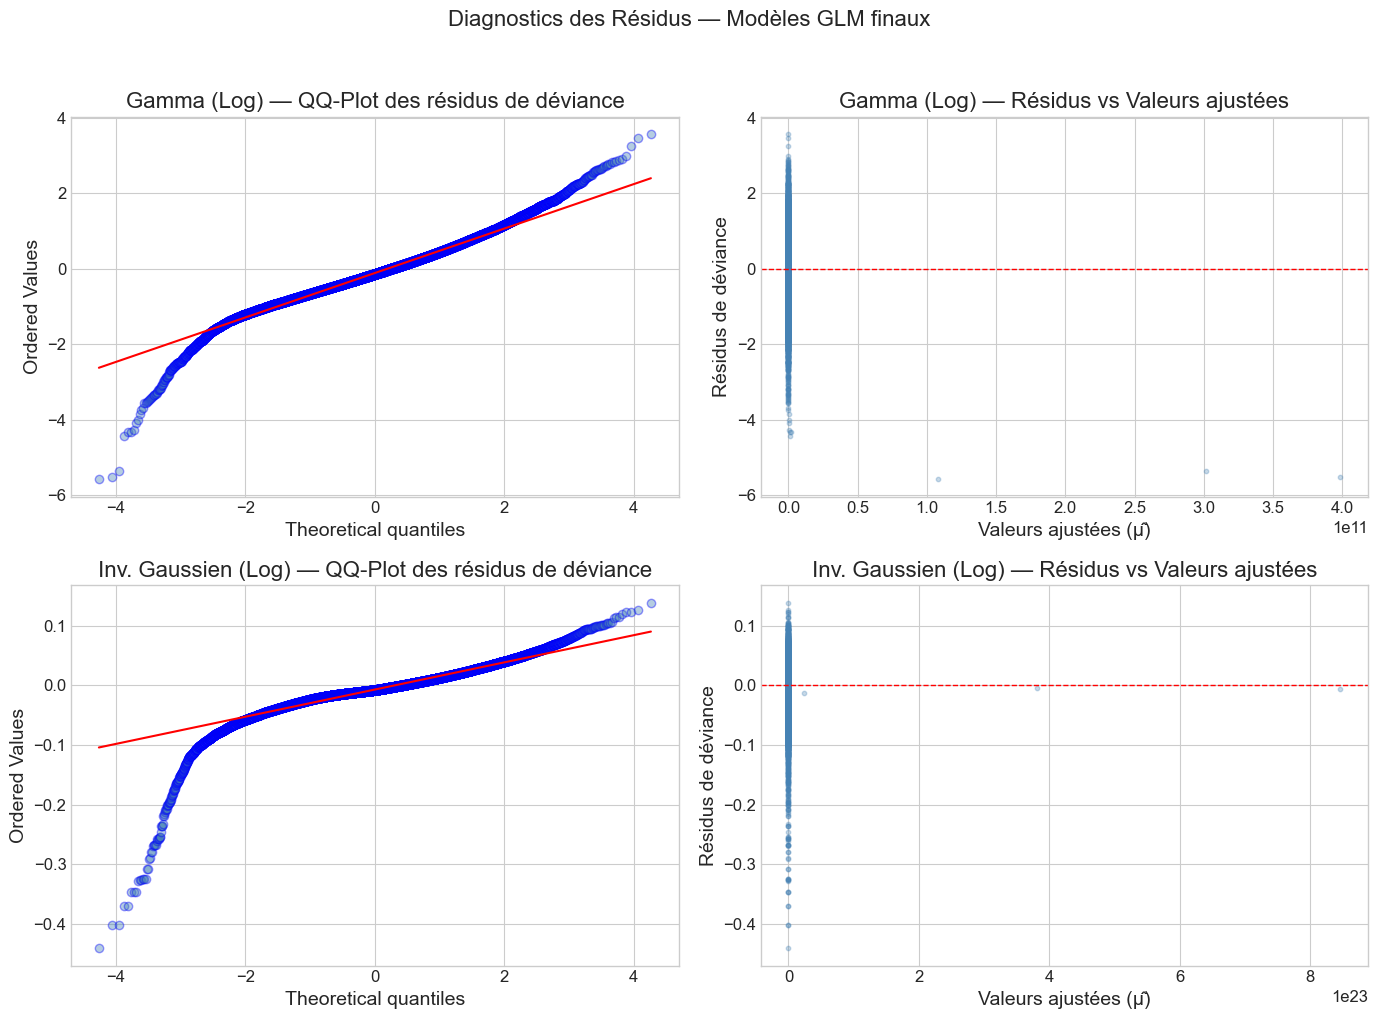


=== Gamma (Log) : Résidus de déviance ===
  Moyenne     : -0.1170  (idéal ≈ 0)
  Écart-type  : 0.5927
  Skewness    : 0.1223  (idéal ≈ 0)
  Kurtosis    : 1.7648  (idéal ≈ 0)

=== Inv. Gaussien (Log) : Résidus de déviance ===
  Moyenne     : -0.0069  (idéal ≈ 0)
  Écart-type  : 0.0240
  Skewness    : -1.5637  (idéal ≈ 0)
  Kurtosis    : 18.1417  (idéal ≈ 0)


In [23]:
# ============================================================
# DIAGNOSTICS DES RÉSIDUS (MODÈLES FINAUX)
# ============================================================

from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Diagnostics des Résidus — Modèles GLM finaux', fontsize=16, y=1.02)

models = {
    'Gamma (Log)': result_gamma,
    'Inv. Gaussien (Log)': result_invgauss,
}

for idx, (name, result) in enumerate(models.items()):
    resid_deviance = result.resid_deviance
    fitted = result.fittedvalues

    # --- QQ-Plot ---
    ax_qq = axes[idx, 0]
    sp_stats.probplot(resid_deviance, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{name} — QQ-Plot des résidus de déviance')
    ax_qq.get_lines()[0].set_markerfacecolor('steelblue')
    ax_qq.get_lines()[0].set_alpha(0.4)

    # --- Résidus vs Valeurs Ajustées ---
    ax_rv = axes[idx, 1]
    ax_rv.scatter(fitted, resid_deviance, alpha=0.3, s=10, color='steelblue')
    ax_rv.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax_rv.set_xlabel('Valeurs ajustées (μ̂)')
    ax_rv.set_ylabel('Résidus de déviance')
    ax_rv.set_title(f'{name} — Résidus vs Valeurs ajustées')

plt.tight_layout()
plt.show()

# --- Résumé numérique ---
for name, result in models.items():
    resid = result.resid_deviance
    print(f"\n=== {name} : Résidus de déviance ===")
    print(f"  Moyenne     : {resid.mean():.4f}  (idéal ≈ 0)")
    print(f"  Écart-type  : {resid.std():.4f}")
    print(f"  Skewness    : {sp_stats.skew(resid):.4f}  (idéal ≈ 0)")
    print(f"  Kurtosis    : {sp_stats.kurtosis(resid):.4f}  (idéal ≈ 0)")

---
## 12. Prédictions GLM sur les Dossiers TEST

In [24]:
# ============================================================
# PRÉDICTIONS FINALES SUR LES DOSSIERS TEST
# ============================================================
# Les dossiers TEST ont une durée inconnue (== 0).
# On applique les modèles GLM finaux (après backward elimination).

# Préparation de X_test avec les mêmes dummies que le train
X_test_all = pd.get_dummies(base_test[all_vars], drop_first=True) * 1
X_test_all = X_test_all.reindex(columns=X_train.columns.drop('const'), fill_value=0)
X_test_all = sm.add_constant(X_test_all)

# Prédictions avec les colonnes retenues par chaque modèle final
base_test = base_test.copy()
base_test['pred_gamma'] = result_gamma.predict(X_test_all[cols_gamma])
base_test['pred_invgauss'] = result_invgauss.predict(X_test_all[cols_invgauss])

# Statistiques descriptives
pred_stats = pd.DataFrame({
    'Gamma': base_test['pred_gamma'].describe(),
    'Inv. Gaussien': base_test['pred_invgauss'].describe(),
})

print(f"=== Prédictions sur {len(base_test)} dossiers TEST (durée inconnue) ===\n")
print(pred_stats.round(1))

# Export
base_test.to_csv('../data/processed/predictions_test.csv', index=False)
print(f"\n✓ Prédictions exportées dans predictions_test.csv")

=== Prédictions sur 13041 dossiers TEST (durée inconnue) ===

           Gamma  Inv. Gaussien
count    13041.0   1.304100e+04
mean      1317.1   1.071599e+06
std      31891.2   1.029332e+08
min        285.3   2.006000e+02
25%        454.6   3.133000e+02
50%        555.4   4.014000e+02
75%        795.1   6.699000e+02
max    3430992.4   1.151373e+10

✓ Prédictions exportées dans predictions_test.csv


---
## Conclusion

### Résultats de l'analyse statistique

- **La cause d'intervention** influence significativement la durée (Kruskal-Wallis, p < 0.001)
- **Le type d'énergie** impacte également la durée (p < 0.001)
- **Les services d'assistance** (VR, Rapatriement, Poursuite) augmentent significativement la durée
- Le **nombre d'intervenants** est le prédicteur le plus fortement corrélé à la durée (Spearman ρ ~ 0.7)
- Le **télétravail** et l'**expérience** ont une corrélation faiblement négative avec la durée

### Résultats de la modélisation (2 modèles GLM)

| Modèle | Famille | Lien | Sélection |
|--------|---------|------|-----------|
| **GLM Gamma** | Gamma | Log | Backward elimination (p < 0.05) |
| **GLM Inverse Gaussien** | Inv. Gaussienne | Log | Backward elimination (p < 0.05) |

**Démarche** :
1. Ajustement du modèle complet (toutes les variables)
2. Backward elimination : retrait itératif de la variable la moins significative (p > 5%)
3. Comparaison des modèles finaux par AIC + métriques sur jeu de validation (80/20)

Le meilleur modèle est sélectionné par l'AIC et validé par les métriques (MAE, RMSE, R²) sur le jeu de validation.

### Facteurs les plus impactants

- **Augmentent la durée** : VR, Rapatriement, Poursuite, Population CAS
- **Réduisent la durée** : Panne mécanique, Clés/Carburant/Crevaison, Télétravail